In [1]:
from sklearn.neural_network import MLPClassifier
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import joblib

In [8]:
df = pd.read_csv('../results/imageFeatures/ResNet50_imagenet/32k_resnet50.csv')

print(df.head())

  image_filename  feature_0  feature_1  feature_2  feature_3  feature_4  \
0      00000.jpg   1.450085   0.042131   0.180524   1.935456   0.197728   
1      00002.jpg   0.007521   0.258690   0.072641   1.297689   0.090251   
2      00003.jpg   0.028916   0.235305   0.074990   1.277185   0.708307   
3      00006.jpg   0.009147   0.049330   0.131912   0.586652   0.055692   
4      00009.jpg   0.012595   0.096588   0.044405   1.037342   0.236773   

   feature_5  feature_6  feature_7  feature_8  ...  feature_2039  \
0   0.041573   0.090296   0.000000   0.000000  ...      0.060531   
1   0.035205   0.968783   1.921228   0.057455  ...      0.208425   
2   0.000000   0.073266   0.043824   0.000000  ...      0.068787   
3   0.201346   0.429702   0.309534   0.000000  ...      0.013758   
4   0.000000   0.157149   0.561915   0.028089  ...      0.081766   

   feature_2040  feature_2041  feature_2042  feature_2043  feature_2044  \
0      0.112489      3.987244      0.166392      0.000000      0.

In [9]:
X = df.drop(columns=['image_filename','class'])
y = df['class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)


In [29]:
clf = MLPClassifier(
        hidden_layer_sizes=(2048, 1024, 512, 256, 128, 64, 32),
        activation='relu',
        solver='adam',
        random_state=420,
        verbose=True,
        learning_rate='invscaling',
    )

In [30]:
clf.fit(X_train, y_train)

Iteration 1, loss = 0.42125238
Iteration 2, loss = 0.27906636
Iteration 3, loss = 0.22066049
Iteration 4, loss = 0.18533371
Iteration 5, loss = 0.14748415
Iteration 6, loss = 0.14788553
Iteration 7, loss = 0.09918834
Iteration 8, loss = 0.08088614
Iteration 9, loss = 0.06680496
Iteration 10, loss = 0.05824646
Iteration 11, loss = 0.05165636
Iteration 12, loss = 0.03495169
Iteration 13, loss = 0.03204002
Iteration 14, loss = 0.02942360
Iteration 15, loss = 0.02955683
Iteration 16, loss = 0.02982009
Iteration 17, loss = 0.02763060
Iteration 18, loss = 0.02533395
Iteration 19, loss = 0.02453781
Iteration 20, loss = 0.01973235
Iteration 21, loss = 0.02072169
Iteration 22, loss = 0.01469104
Iteration 23, loss = 0.01705179
Iteration 24, loss = 0.01382979
Iteration 25, loss = 0.01281120
Iteration 26, loss = 0.01069982
Iteration 27, loss = 0.01470398
Iteration 28, loss = 0.01641902
Iteration 29, loss = 0.01559193
Iteration 30, loss = 0.01382631
Iteration 31, loss = 0.01445091
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(2048, 1024, 512, 256, 128, 64, 32),
              learning_rate='invscaling', random_state=420, verbose=True)

In [31]:
predictions = clf.predict(X_test)

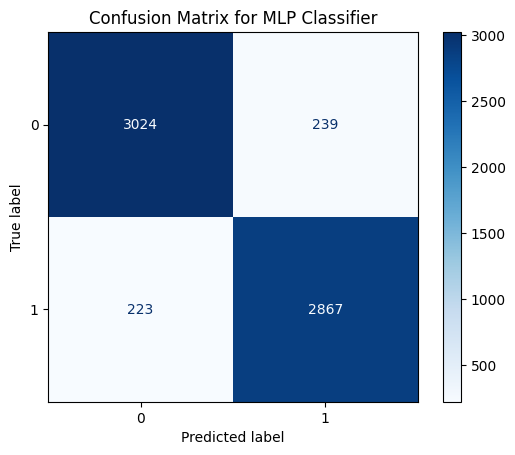

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      3263
           1       0.92      0.93      0.93      3090

    accuracy                           0.93      6353
   macro avg       0.93      0.93      0.93      6353
weighted avg       0.93      0.93      0.93      6353

Accuracy: 0.9272784511254526
Precision: 0.9230521571152608
Recall: 0.927831715210356
F1 Score: 0.9254357650096837


In [32]:
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MLP Classifier')
plt.show()
print(classification_report(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))


In [ ]:
joblib.dump(clf, 'mlp_classifier_32k.joblib')

['mlp_classifier_32k.joblib']

## TEST

In [2]:
model = joblib.load('mlp_classifier_32k.joblib')
test = pd.read_csv('../results/imageFeatures/ResNet50_imagenet/290k.csv')
print(test.head())

  image_filename  feature_0  feature_1  feature_2  feature_3  feature_4  \
0      00000.jpg   1.450086   0.042131   0.180524   1.935458   0.197728   
1      00000.png   0.982745   0.000000   0.145935   2.135390   0.333342   
2      00001.png   0.026971   0.085121   0.138966   1.367433   0.195734   
3      00002.jpg   0.007521   0.258690   0.072641   1.297689   0.090250   
4      00002.png   0.013343   0.148255   0.026248   0.809152   0.133711   

   feature_5  feature_6  feature_7  feature_8  ...  feature_2039  \
0   0.041573   0.090296   0.000000   0.000000  ...      0.060531   
1   0.091772   0.125049   0.000000   0.000000  ...      0.023535   
2   0.000000   0.380838   0.261585   0.000000  ...      0.487259   
3   0.035205   0.968784   1.921226   0.057455  ...      0.208425   
4   0.021138   1.043707   1.253339   0.057420  ...      0.195955   

   feature_2040  feature_2041  feature_2042  feature_2043  feature_2044  \
0      0.112489      3.987245      0.166393      0.000000      0.

In [3]:
X = test.drop(columns=['image_filename','class'])
y = test['class']

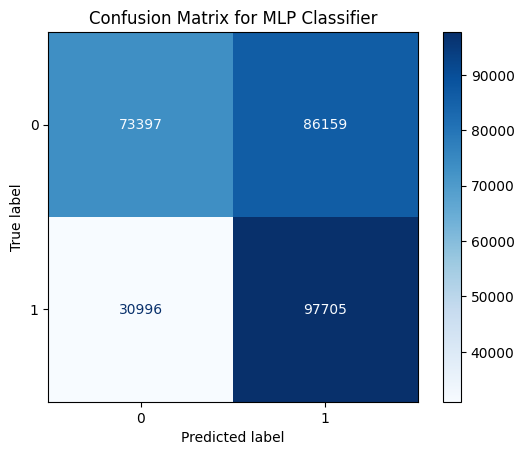

              precision    recall  f1-score   support

           0       0.70      0.46      0.56    159556
           1       0.53      0.76      0.63    128701

    accuracy                           0.59    288257
   macro avg       0.62      0.61      0.59    288257
weighted avg       0.63      0.59      0.59    288257

Accuracy: 0.5935744838807037
Precision: 0.5313982073706652
Recall: 0.7591627104684501
F1 Score: 0.6251819621518724


In [4]:
model_predictions = model.predict(X)

cm = confusion_matrix(y, model_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MLP Classifier')
plt.show()
print(classification_report(y, model_predictions))
print("Accuracy:", accuracy_score(y, model_predictions))
print("Precision:", precision_score(y, model_predictions))
print("Recall:", recall_score(y, model_predictions))
print("F1 Score:", f1_score(y, model_predictions))